In [1]:
import geopandas as gpd

# 1. Carregar os ficheiros
# Nota: Para o .gpkg, se houver várias camadas, especifique o layer_name
areas_ptd = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("polígonos_Aveiro.shp")

# 2. Garantir que ambos estão no mesmo Sistema de Coordenadas (SCR)
# Se não estiverem, o spatial join falhará ou será impreciso
if edificios.crs != areas_ptd.crs:
    edificios = edificios.to_crs(areas_ptd.crs)

# 3. Spatial Join (Equivalente ao "Unir atributos por localização" do QGIS)
# Isto atribui a cada edifício a informação da área de PTD onde ele está contido
edificios_com_ptd = gpd.sjoin(edificios, areas_ptd, how="inner", predicate="within")

# 4. Agrupar e contar as tipologias únicas por PTD
# Substitua 'ID_PTD' e 'Tipologia' pelos nomes exatos das colunas nos seus ficheiros
analise_diversidade = edificios_com_ptd.groupby('ptd_id')['Layer'].nunique().reset_index()

# 5. Criar uma coluna de classificação
analise_diversidade['diversidade'] = analise_diversidade['Layer'].apply(
    lambda x: 'Mista' if x > 1 else 'Única'
)

# 6. Ver os resultados
print(analise_diversidade)

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.

In [2]:
import geopandas as gpd

# 1. Carregar os ficheiros originais
areas_ptd = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("polígonos_Aveiro.shp")

# 2. RESOLUÇÃO DO ERRO: Atribuir um SCR caso esteja em falta ("naive")
if edificios.crs is None:
    # Cenário A: Se os edifícios já foram desenhados na mesma escala/coordenadas que os PTDs,
    # apenas forçamos o mesmo sistema do PTD para que o GeoPandas o reconheça:
    print("Aviso: O ficheiro de edifícios não tem SCR definido. A assumir o mesmo do PTD...")
    edificios = edificios.set_crs(areas_ptd.crs)
    
    # Cenário B (Se após correr o código os mapas não alinharem no QGIS): 
    # Significa que o Shapefile original usa o sistema oficial de Portugal Continental (PT-TM06).
    # Se isso acontecer, elimine o símbolo '#' da linha de baixo para ativar:
    # edificios = edificios.set_crs("EPSG:3763")

# Agora que o edifício já tem um SCR base associado, podemos harmonizar em segurança
if edificios.crs != areas_ptd.crs:
    edificios = edificios.to_crs(areas_ptd.crs)

# 3. Cruzamento Espacial (Saber em que PTD está cada edifício)
edificios_nos_ptd = gpd.sjoin(edificios, areas_ptd, how="inner", predicate="within")

# 4. Criar filtros robustos usando a coluna 'Layer' (ignorando maiúsculas/minúsculas)
edificios_nos_ptd['Layer_upper'] = edificios_nos_ptd['Layer'].astype(str).str.upper()

industriais = edificios_nos_ptd[edificios_nos_ptd['Layer_upper'].str.contains("INDUSTRIAL", na=False)]
permanentes = edificios_nos_ptd[edificios_nos_ptd['Layer_upper'].str.contains("PERMANENTE", na=False)]

# 5. Descobrir quais os IDs de PTD que contêm AMBOS os tipos em simultâneo
ptds_com_industriais = set(industriais['ptd_id'].unique())
ptds_com_permanentes = set(permanentes['ptd_id'].unique())

# A interseção ( & ) garante que só guardamos os PTDs que aparecem em ambas as listas
ptds_mistos_ids = ptds_com_industriais.intersection(ptds_com_permanentes)

# 6. Filtrar as áreas PTD originais para manter APENAS estas áreas mistas
areas_ptd_mistas = areas_ptd[areas_ptd['ptd_id'].isin(ptds_mistos_ids)].copy()

# 7. Adicionar colunas com a contagem exata para ver no QGIS/Excel
contagem_ind = industriais.groupby('ptd_id').size().rename('qtd_industriais')
contagem_perm = permanentes.groupby('ptd_id').size().rename('qtd_permanentes')

areas_ptd_mistas = areas_ptd_mistas.merge(contagem_ind, on='ptd_id', how='left').fillna(0)
areas_ptd_mistas = areas_ptd_mistas.merge(contagem_perm, on='ptd_id', how='left').fillna(0)

# Ver resumo no ecrã do Jupyter
print(f"Sucesso! Foram encontradas {len(areas_ptd_mistas)} áreas PTD mistas (Industrial + Permanente).")
print(areas_ptd_mistas[['ptd_id', 'qtd_industriais', 'qtd_permanentes']].head())

# 8. Exportar para um novo ficheiro GeoPackage (contém os polígonos destas áreas)
areas_ptd_mistas.to_file("PTD_Areas_Mistas_Ocupacao.gpkg", layer="areas_mistas", driver="GPKG")

Aviso: O ficheiro de edifícios não tem SCR definido. A assumir o mesmo do PTD...


KeyError: 'Layer'

In [ ]:
print(areas_ptd.columns)
print(edificios.columns)

Index(['ptd_id', 'n_nos', 'area_km2', 'geometry'], dtype='str')
Index(['fid', 'Layer', 'PaperSpace', 'SubClasses', 'Linetype', 'EntityHand',
       'Text', 'src_file', 'texto_limp', 'area_m2', 'source_lay', 'polygon_id',
       'altura_edi', 'cota_topo_', 'cota_terre', 'dist_curva', 'n_points_h',
       'qa_altura_', 'qa_longe_c', 'qa_rever', 'has_height', 'geometry'],
      dtype='str')


C:\Users\gabri\AppData\Local\Temp\ipykernel_17868\4125960620.py:34: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  ptds[ptds['tipo_zona'] == 'Mista'].plot(


Mapa gerado com sucesso! Identificadas 176 áreas mistas.


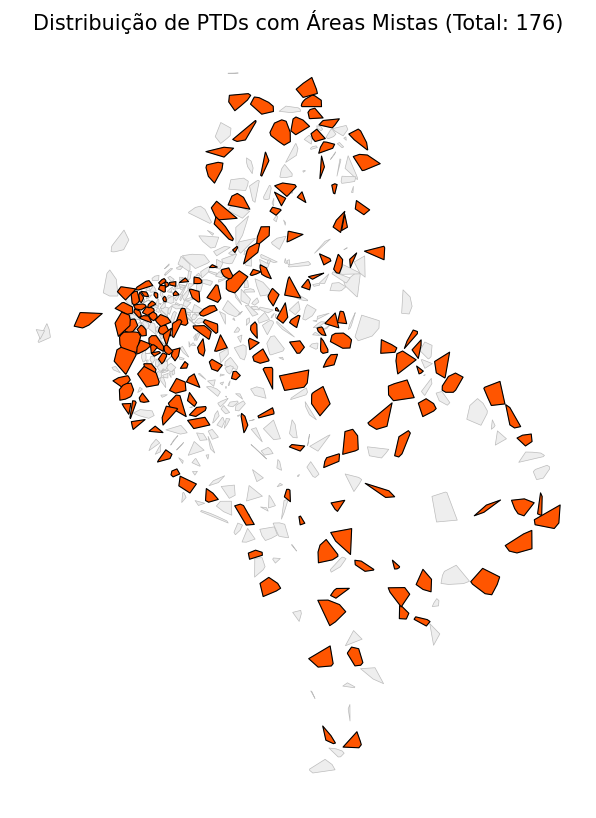

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Carregar os dados
# Certifique-se de que o .dbf e .shx estão na mesma pasta que o .shp
ptds = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("polígonos_Aveiro.shp")

# 2. Harmonizar o Sistema de Coordenadas (SCR)
if edificios.crs != ptds.crs:
    edificios = edificios.to_crs(ptds.crs)

# 3. Identificar Áreas Mistas (Spatial Join + Agrupamento)
# Fazemos o join para saber em que PTD está cada edifício
join = gpd.sjoin(edificios, ptds, how="inner", predicate="within")

# Contamos quantas tipologias únicas existem por cada ID de PTD
# Substitua 'ptd_id' e 'tipologia' pelos nomes reais das colunas
stats = join.groupby('ptd_id')['Layer'].nunique().reset_index()

# Criamos uma lista dos IDs que têm mais de 1 tipo de edifício
ids_mistos = stats[stats['Layer'] > 1]['ptd_id'].tolist()

# 4. Criar o Mapa
# Criamos uma coluna nova no GeoDataFrame original para a legenda
ptds['tipo_zona'] = ptds['ptd_id'].apply(lambda x: 'Mista' if x in ids_mistos else 'Homogénea')

fig, ax = plt.subplots(figsize=(12, 10))

# Desenhar todas as áreas (fundo cinza claro)
ptds.plot(ax=ax, color='#eeeeee', edgecolor='#bcbcbc', linewidth=0.5)

# Desenhar apenas as áreas mistas com uma cor de destaque
ptds[ptds['tipo_zona'] == 'Mista'].plot(
    ax=ax, 
    column='tipo_zona', 
    color='#ff5500', 
    edgecolor='black', 
    linewidth=0.8,
    label='Áreas Mistas (Tipologias Variadas)'
)

# Adicionar título e formatação
plt.title(f'Distribuição de PTDs com Áreas Mistas (Total: {len(ids_mistos)})', fontsize=15)
ax.set_axis_off() # Remove as coordenadas para o mapa ficar limpo

# Guardar o mapa como imagem
plt.savefig("mapa_areas_mistas.png", dpi=300, bbox_inches='tight')
print(f"Mapa gerado com sucesso! Identificadas {len(ids_mistos)} áreas mistas.")

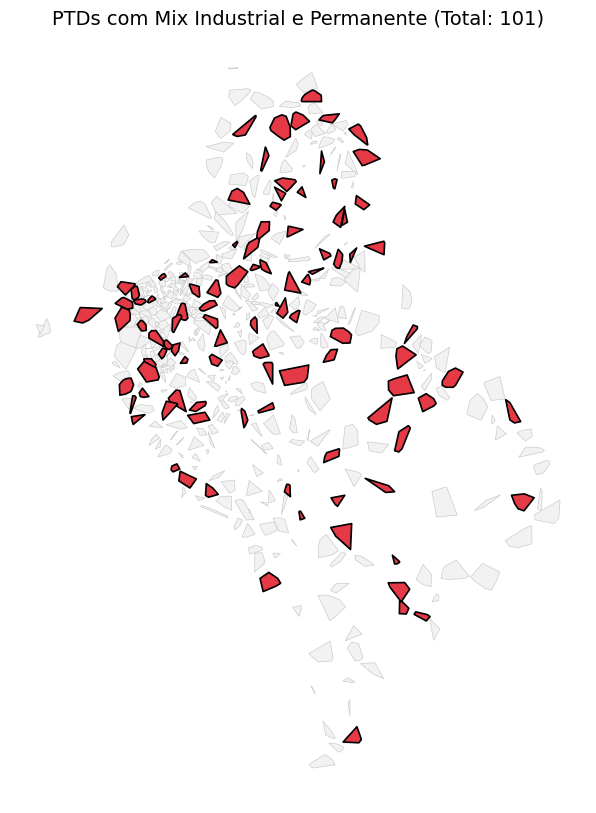

Foram identificados 101 PTDs com ambos os tipos.


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Carregar os dados
ptds = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("polígonos_Aveiro.shp")

# 2. Harmonizar o SCR
if edificios.crs != ptds.crs:
    edificios = edificios.to_crs(ptds.crs)

# 3. União Espacial
join = gpd.sjoin(edificios, ptds, how="inner", predicate="within")

# 4. Lógica de filtragem corrigida para os nomes das camadas
def tem_industrial_e_permanente(tipologias):
    # Transformamos tudo numa string única para pesquisar palavras-chave
    lista_tipos = " ".join(tipologias)
    tem_ind = "INDUSTRIAL" in lista_tipos
    tem_perm = "PERMANENTE" in lista_tipos
    return tem_ind and tem_perm

# Agrupar e aplicar a nova lógica
# (Certifica-te que 'ptd_id' e 'Layer' são os nomes das colunas)
resultado = join.groupby('ptd_id')['Layer'].apply(tem_industrial_e_permanente).reset_index()

# IDs das áreas que cumprem o critério
ids_alvo = resultado[resultado['Layer'] == True]['ptd_id'].tolist()

# 5. Criar o Mapa de Destaque
ptds['destaque'] = ptds['ptd_id'].isin(ids_alvo)

fig, ax = plt.subplots(figsize=(12, 10))

# Desenhar base (todas as áreas)
ptds.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.5)

# Desenhar apenas as áreas Industriais + Permanentes
if len(ids_alvo) > 0:
    ptds[ptds['destaque']].plot(
        ax=ax, 
        color='#e63946', 
        edgecolor='black', 
        linewidth=1.2,
        label='Industrial + Permanente'
    )
    plt.title(f'PTDs com Mix Industrial e Permanente (Total: {len(ids_alvo)})', fontsize=14)
else:
    plt.title('Nenhuma área encontrada com os critérios exatos', fontsize=14)

ax.set_axis_off()
plt.show()

print(f"Foram identificados {len(ids_alvo)} PTDs com ambos os tipos.")

In [ ]:
import geopandas as gpd

# 1. Carregar os ficheiros
areas_ptd = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("polígonos_Aveiro.shp")

# 2. Garantir o mesmo Sistema de Coordenadas (SCR)
if edificios.crs != areas_ptd.crs:
    edificios = edificios.to_crs(areas_ptd.crs)

# 3. Cruzamento Espacial (Saber em que PTD está cada edifício)
# Nota: Substitua 'ptd_id' pelo nome correto da coluna identificadora do PTD se for diferente
edificios_nos_ptd = gpd.sjoin(edificios, areas_ptd, how="inner", predicate="within")

# 4. Identificar as colunas de tipologia
# NOTA: Altere 'Designacao' para o nome exato da coluna que diz se é "Industrial" ou "Permanente"
coluna_tipo = 'Designacao' 

# Criamos filtros para isolar apenas o que nos interessa
industriais = edificios_nos_ptd[edificios_nos_ptd[coluna_tipo] == "Industrial"]
permanentes = edificios_nos_ptd[edificios_nos_ptd[coluna_tipo] == "Permanente"]

# 5. Descobrir quais os IDs de PTD que têm edifícios Industriais E também Permanentes
ptds_com_industriais = set(industriais['ptd_id'].unique())
ptds_com_permanentes = set(permanentes['ptd_id'].unique())

# A interseção ( & ) dá-nos apenas os PTDs que aparecem em ambas as listas ao mesmo tempo
ptds_mistos_ids = ptds_com_industriais.intersection(ptds_com_permanentes)

# 6. Filtrar o mapa original de PTDs para guardar apenas estas áreas mistas
areas_ptd_mistas = areas_ptd[areas_ptd['ptd_id'].isin(ptds_mistos_ids)].copy()

# 7. Adicionar informação visual/estatística (Opcional, mas útil)
# Vamos contar quantos edifícios de cada tipo existem nessas áreas
contagem_ind = industriais.groupby('ptd_id').size().rename('qtd_industriais')
contagem_perm = permanentes.groupby('ptd_id').size().rename('qtd_permanentes')

areas_ptd_mistas = areas_ptd_mistas.merge(contagem_ind, on='ptd_id', how='left')
areas_ptd_mistas = areas_ptd_mistas.merge(contagem_perm, on='ptd_id', how='left')

# Ver o resultado no ecrã
print(f"Encontradas {len(areas_ptd_mistas)} áreas PTD mistas (com edifícios industriais e permanentes).")
print(areas_ptd_mistas[['ptd_id', 'qtd_industriais', 'qtd_permanentes']].head())

# 8. Guardar o ficheiro final apenas com as geometrias das áreas PTD mistas
areas_ptd_mistas.to_file("PTD_Areas_Mistas.gpkg", layer="areas_mistas", driver="GPKG")

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.

In [3]:
import geopandas as gpd
import os

# ==============================================================================
# 1. CARREGAR OS DADOS
# ==============================================================================
print("A carregar os ficheiros...")
# Ficheiro com as áreas de influência dos PTD
areas_ptd = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")

# Ficheiro com os edifícios (use o ficheiro gerado anteriormente que já tem os tipos na coluna 'Layer')
# Se ainda usar o .gpkg multicamadas, certifique-se de carregar o que tem a tabela completa.
edificios = gpd.read_file("MstCSCS_Sem_2526.gpkg") 

# Nota: Se a coluna com os tipos for diferente de 'Layer' (ex: 'Designacao'), altere aqui:
coluna_tipo = 'Layer'

# ==============================================================================
# 2. HARMONIZAR OS SISTEMAS DE COORDENADAS (SCR)
# ==============================================================================
if areas_ptd.crs is None:
    areas_ptd = areas_ptd.set_crs("EPSG:3763")
if edificios.crs is None:
    edificios = edificios.set_crs("EPSG:3763")

if edificios.crs != areas_ptd.crs:
    edificios = edificios.to_crs(areas_ptd.crs)

# Limpeza preventiva de colunas internas para evitar o erro 'fid'
for df in [edificios, areas_ptd]:
    if 'fid' in df.columns:
        df.drop(columns=['fid'], inplace=True)

# ==============================================================================
# 3. CRUZAMENTO ESPACIAL (Unir edifícios com as áreas PTD)
# ==============================================================================
print("A cruzar os edifícios com as áreas de influência PTD...")
# Isto atribui a cada edifício as colunas do PTD onde ele está inserido (ex: 'ptd_id')
edificios_com_ptd = gpd.sjoin(edificios, areas_ptd, how="inner", predicate="within")

if 'index_right' in edificios_com_ptd.columns:
    edificios_com_ptd = edificios_com_ptd.drop(columns=['index_right'])

# GUARDAR RESULTADO 1: Todos os edifícios com a informação de a que PTD pertencem
ficheiro_saida_1 = "Edificios_por_Area_PTD.gpkg"
edificios_com_ptd.to_file(ficheiro_saida_1, driver="GPKG")
print(f"-> Ficheiro 1 guardado: '{ficheiro_saida_1}'")


# ==============================================================================
# 4. IDENTIFICAR ÁREAS PTD MISTAS (> 1 TIPO DE EDIFÍCIO)
# ==============================================================================
print("A calcular a diversidade de tipos por cada PTD...")

# Contar quantos tipos ('Layer') únicos existem em cada 'ptd_id'
contagem_tipos = edificios_com_ptd.groupby('ptd_id')[coluna_tipo].nunique().reset_index()
contagem_tipos.rename(columns={coluna_tipo: 'qtd_tipos_diferentes'}, inplace=True)

# Filtrar apenas os IDs de PTD que têm mais do que 1 tipo de edifício
ptds_mistos_ids = contagem_tipos[contagem_tipos['qtd_tipos_diferentes'] > 1]['ptd_id'].tolist()

# Filtrar o mapa original de PTDs para guardar apenas estas áreas
areas_mistas_geral = areas_ptd[areas_ptd['ptd_id'].isin(ptds_mistos_ids)].copy()
# Anexar a contagem para conseguir ver o número de tipos no QGIS
areas_mistas_geral = areas_mistas_geral.merge(contagem_tipos, on='ptd_id', how='left')

# GUARDAR RESULTADO 2: Polígonos das áreas PTD com mais de uma atividade
ficheiro_saida_2 = "PTD_Areas_Mistas_Geral.gpkg"
areas_mistas_geral.to_file(ficheiro_saida_2, driver="GPKG")
print(f"-> Ficheiro 2 guardado: '{ficheiro_saida_2}' (Total: {len(areas_mistas_geral)} áreas)")


# ==============================================================================
# 5. FILTRAR APENAS AS ÁREAS MISTAS COM: PERMANENTE E INDUSTRIAL
# ==============================================================================
print("A filtrar PTDs mistos com a combinação exata (Permanente + Industrial)...")

# Colocar os textos em maiúsculas para evitar erros de digitação (ex: "industrial" vs "INDUSTRIAL")
edificios_com_ptd['tipo_maiusculo'] = edificios_com_ptd[coluna_tipo].astype(str).str.upper()

# Criar dois grupos isolados baseados no termo que procura
ind_ids = edificios_com_ptd[edificios_com_ptd['tipo_maiusculo'].str.contains("INDUSTRIAL", na=False)]['ptd_id'].unique()
perm_ids = edificios_com_ptd[edificios_com_ptd['tipo_maiusculo'].str.contains("PERMANENTE", na=False)]['ptd_id'].unique()

# A interseção de conjuntos dá-nos os IDs que contêm simultaneamente os dois tipos
ptds_perm_e_ind_ids = list(set(ind_ids).intersection(set(perm_ids)))

# Filtrar o mapa original de PTDs apenas por estes IDs específicos
areas_mistas_especificas = areas_ptd[areas_ptd['ptd_id'].isin(ptds_perm_e_ind_ids)].copy()

# Opcional: Contar quantos de cada tipo existem nestas áreas específicas para enriquecer os dados
qtd_ind = edificios_com_ptd[edificios_com_ptd['tipo_maiusculo'].str.contains("INDUSTRIAL")].groupby('ptd_id').size().rename('qtd_industriais')
qtd_perm = edificios_com_ptd[edificios_com_ptd['tipo_maiusculo'].str.contains("PERMANENTE")].groupby('ptd_id').size().rename('qtd_permanentes')

areas_mistas_especificas = areas_mistas_especificas.merge(qtd_ind, on='ptd_id', how='left').fillna(0)
areas_mistas_especificas = areas_mistas_especificas.merge(qtd_perm, on='ptd_id', how='left').fillna(0)

# GUARDAR RESULTADO 3: Apenas os polígonos das áreas mistas com a combinação exata pedida
ficheiro_saida_3 = "PTD_Areas_Mistas_Permanente_Industrial.gpkg"
areas_mistas_especificas.to_file(ficheiro_saida_3, driver="GPKG")
print(f"-> Ficheiro 3 guardado: '{ficheiro_saida_3}' (Total: {len(areas_mistas_especificas)} áreas)")

print("\n!!! Análise finalizada com sucesso !!!")

A carregar os ficheiros...


c:\Users\gabri\miniforge3\envs\envEOAD_statsPythonR\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'MstCSCS_Sem_2526.gpkg': 'ed12_polygons_all_with_heights_clean' (default), 'avr_npolicia_pts', 'postal_code_buildings_assigned'. Specify layer parameter to avoid this warning.
  result = read_func(


A cruzar os edifícios com as áreas de influência PTD...
-> Ficheiro 1 guardado: 'Edificios_por_Area_PTD.gpkg'
A calcular a diversidade de tipos por cada PTD...
-> Ficheiro 2 guardado: 'PTD_Areas_Mistas_Geral.gpkg' (Total: 176 áreas)
A filtrar PTDs mistos com a combinação exata (Permanente + Industrial)...
-> Ficheiro 3 guardado: 'PTD_Areas_Mistas_Permanente_Industrial.gpkg' (Total: 101 áreas)

!!! Análise finalizada com sucesso !!!


A carregar os ficheiros geográficos...


c:\Users\gabri\miniforge3\envs\envEOAD_statsPythonR\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'MstCSCS_Sem_2526.gpkg': 'ed12_polygons_all_with_heights_clean' (default), 'avr_npolicia_pts', 'postal_code_buildings_assigned'. Specify layer parameter to avoid this warning.
  result = read_func(


A cruzar espacialmente os edifícios com as áreas de influência...


C:\Users\gabri\AppData\Local\Temp\ipykernel_5796\3275371199.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  areas_ptd['is_mista_geral'] = areas_ptd['is_mista_geral'].fillna(False)
C:\Users\gabri\AppData\Local\Temp\ipykernel_5796\3275371199.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  areas_ptd['is_mista_perm_ind'] = areas_ptd['is_mista_perm_ind'].fillna(False)


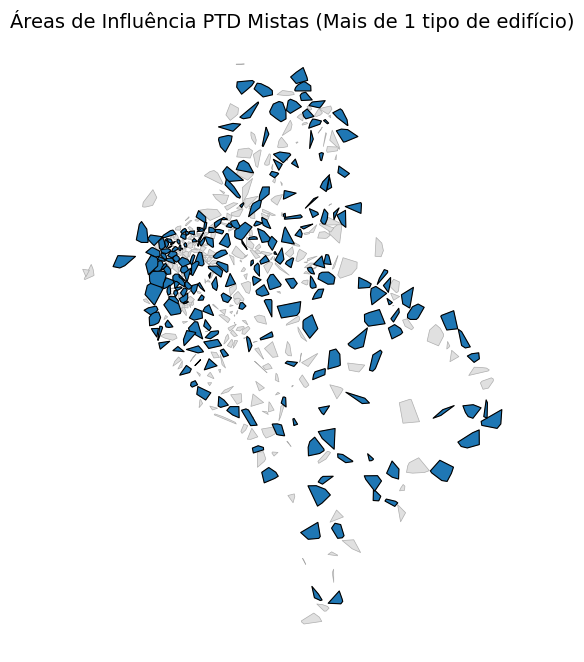

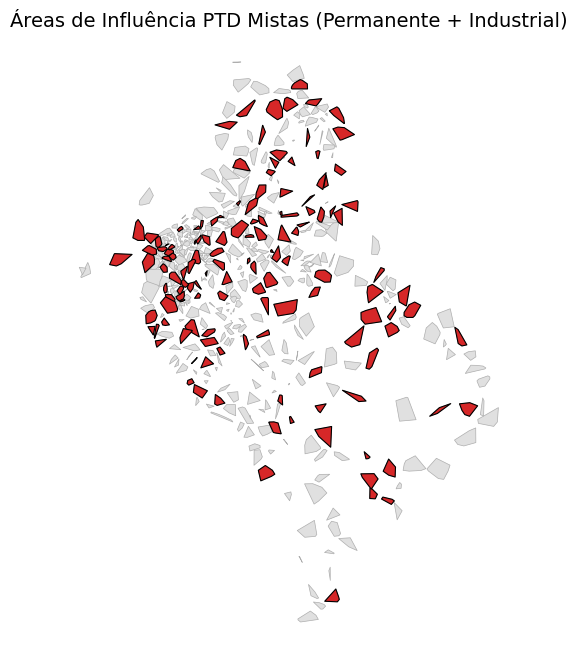

Análise concluída e imagens guardadas com sucesso!


In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Carregar os ficheiros originais
print("A carregar os ficheiros geográficos...")
areas_ptd = gpd.read_file("PTD_Areas_Servico_Rede.gpkg")
edificios = gpd.read_file("MstCSCS_Sem_2526.gpkg")

# 2. Harmonizar o Sistema de Coordenadas (SCR) para garantir precisão
if areas_ptd.crs is None: areas_ptd = areas_ptd.set_crs("EPSG:3763")
if edificios.crs is None: edificios = edificios.set_crs("EPSG:3763")
if edificios.crs != areas_ptd.crs:
    edificios = edificios.to_crs(areas_ptd.crs)

# 3. Cruzamento Espacial (Spatial Join)
# Identifica quais os edifícios que intersetam ou estão dentro de cada PTD
print("A cruzar espacialmente os edifícios com as áreas de influência...")
join_df = gpd.sjoin(edificios, areas_ptd, how="inner", predicate="intersects")

# 4. Agrupar os edifícios por PTD para analisar a diversidade de tipologias
ptd_groups = join_df.groupby('ptd_id')['Layer'].apply(set).reset_index()

# Critério A: Áreas mistas no geral (número de tipos únicos > 1)
ptd_groups['is_mista_geral'] = ptd_groups['Layer'].apply(lambda x: len(x) > 1)

# Critério B: Áreas mistas com a combinação exata (Permanente E Industrial)
ptd_groups['is_mista_perm_ind'] = ptd_groups['Layer'].apply(
    lambda x: 'ED08_EDIF_PERMANENTE' in x and 'ED06_EDIF_INDUSTRIAL' in x
)

# 5. Associar estes resultados de volta ao mapa de polígonos das áreas PTD
areas_ptd = areas_ptd.merge(ptd_groups[['ptd_id', 'is_mista_geral', 'is_mista_perm_ind']], on='ptd_id', how='left')
areas_ptd['is_mista_geral'] = areas_ptd['is_mista_geral'].fillna(False)
areas_ptd['is_mista_perm_ind'] = areas_ptd['is_mista_perm_ind'].fillna(False)

# ==============================================================================
# VISUALIZAÇÃO MAPA 1: Áreas Mistas em Geral (Mais de 1 tipo de uso)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Desenhar todas as zonas de fundo em cinzento claro
areas_ptd.plot(ax=ax, color='#e0e0e0', edgecolor='#aeaeae', linewidth=0.5)

# Destacar a azul as áreas que têm diversidade de usos
areas_ptd[areas_ptd['is_mista_geral']].plot(
    ax=ax, color='#1f77b4', edgecolor='black', linewidth=0.8, label='Áreas Mistas (Geral)'
)

plt.title("Áreas de Influência PTD Mistas (Mais de 1 tipo de edifício)", fontsize=14)
ax.set_axis_off() # Remove as coordenadas das bordas para o mapa ficar limpo
plt.savefig("mapa_ptd_mistas_geral.png", dpi=300, bbox_inches='tight')
plt.show() # Mostra o mapa diretamente dentro do Jupyter Notebook

# ==============================================================================
# VISUALIZAÇÃO MAPA 2: Áreas Mistas Específicas (Permanente + Industrial)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Desenhar todas as zonas de fundo em cinzento claro
areas_ptd.plot(ax=ax, color='#e0e0e0', edgecolor='#aeaeae', linewidth=0.5)

# Destacar a vermelho as áreas com habitação e indústria combinadas
areas_ptd[areas_ptd['is_mista_perm_ind']].plot(
    ax=ax, color='#d62728', edgecolor='black', linewidth=0.8, label='Permanente + Industrial'
)

plt.title("Áreas de Influência PTD Mistas (Permanente + Industrial)", fontsize=14)
ax.set_axis_off()
plt.savefig("mapa_ptd_mistas_perm_ind.png", dpi=300, bbox_inches='tight')
plt.show()

print("Análise concluída e imagens guardadas com sucesso!")